## 1. Introduction
### Pima Indians Diabetes Project🍫


- This project explores how machine learning can be used to predict diabetes using basic clinical measurements.
-Using the Pima Indians Diabetes dataset, several classification models were trained to identify whether a patient is likely to have diabetes.

- The goal of this project is to build a simple and reproducible machine learning pipeline that includes data cleaning, preprocessing, model training, and model evaluation on real medical data.

**Dataset**
Pima Indians Diabetes Dataset (UCI Machine Learning Repository)

768 patient records
8 clinical features: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
Target variable:
0 = No diabetes
1 = Diabetes

**Methods**
The following steps were implemented in the project:
- Data cleaning and handling of medically invalid values
- Exploratory Data Analysis (EDA)
- Preprocessing pipeline (imputation and feature scaling)
- Training multiple classification models
- Model evaluation using accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices
- Identifying the most important predictors of diabetes
- 
**Note**
All analysis, visualizations, and code implementations in this project were developed independently as part of a self‑directed learning project in computational biology.

### Research Questions
This project aims to answer the following questions:

- Can machine learning models predict diabetes using basic clinical measurements?
- Which physiological features are the most important predictors of diabetes?
- Which model performs better for this dataset: Logistic Regression or Random Forest?
- How well can the models identify true diabetes cases?

## 2. Importing Required Libraries
Import libraries for data handling, visualization, modeling, and evaluation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Basic plot settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Model selection and evaluation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Preprocessing and Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


## 3. Load the dataset & define columns

In [2]:
# Load the dataset 

columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv(("diabetes.csv"), header = 0 )# There is a header in the CSV

--------------------------------


## 4. Exploratory Data Analysis (EDA)


###  Data Inspection & Descriptive Statistics

4.1 Check number of rows and columns using df.shape :

In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (768, 9)


- This dataset has 768 samples and 9 columns (8 features + target).


---






4.2 The first 5 rows to understand the dataset structure using df.head() :

In [4]:
print("\nFirst 5 rows:\n", df.head())  # Preview the data


First 5 rows:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


---

4.3 Check Data Types & Missing Values  Using info():


In [5]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


- The data contains several biological features (8) and a target variable (Outcome)

---

4.4 Proportion of Classes (Imbalance Check)

In [6]:
# Map numeric labels to meaningful class names
class_mapping = {
    0: "Non-Diabetic",
    1: "Diabetic"
}

# Calculate normalized class distribution
class_dist = df['Outcome'].value_counts(normalize=True).round(3)

# Apply mapping for readability
class_dist.index = class_dist.index.map(class_mapping)

print("\nClass distribution:")
print(class_dist)



Class distribution:
Outcome
Non-Diabetic    0.651
Diabetic        0.349
Name: proportion, dtype: float64


The dataset is imbalanced : 

Class distributation shows that there are more non-diabetic individuals (Outcome=0) than diabetic ones (Outcome=1).


---



4.5 Summary Statistics of Dataset Using df.describe()

In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


This table displays some statistical operations like count, mean, median(50%),  min, max, standard deviation, Q1(25%), and Q3(75%) for each features.

The dataset contains physiologically and medically impossible zeros in:
* Glucose
* BloodPressure
* SkinThickness
* Insulin
* BMI
  
which requires data cleaning.

-------------------------------------

## 5. Data Cleaning


▸ I considered '0' values as a missing values and replaced them with `NaN` and will later be imputed only using the training set to avoid data leakage.

▸ This step ensures that the model does not learn from medically invalid data.

In [8]:
# Identify columns where zero values are invalid (medically impossible)
cols_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']


# Replace 0 with NaN (Not a Number) in these specific columns
# This prevents the model from treating missing data as actual physiological values
df[cols_with_invalid_zeros] = df[cols_with_invalid_zeros].replace(0, np.nan)


# Count and display the number of missing values (NaN) in each column
print("Number of missing values (NaN) per column:")
print(df.isnull().sum())


Number of missing values (NaN) per column:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


Statistical operations after data cleaning :

In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


-----------------------

## 6. Data Visualization

This section provides a visual and statistical overview of the dataset.

### 6.1 KDE (Kernel Density Estimate) Plot for Comparing 8 features in Diabetic vs. Healthy individuals

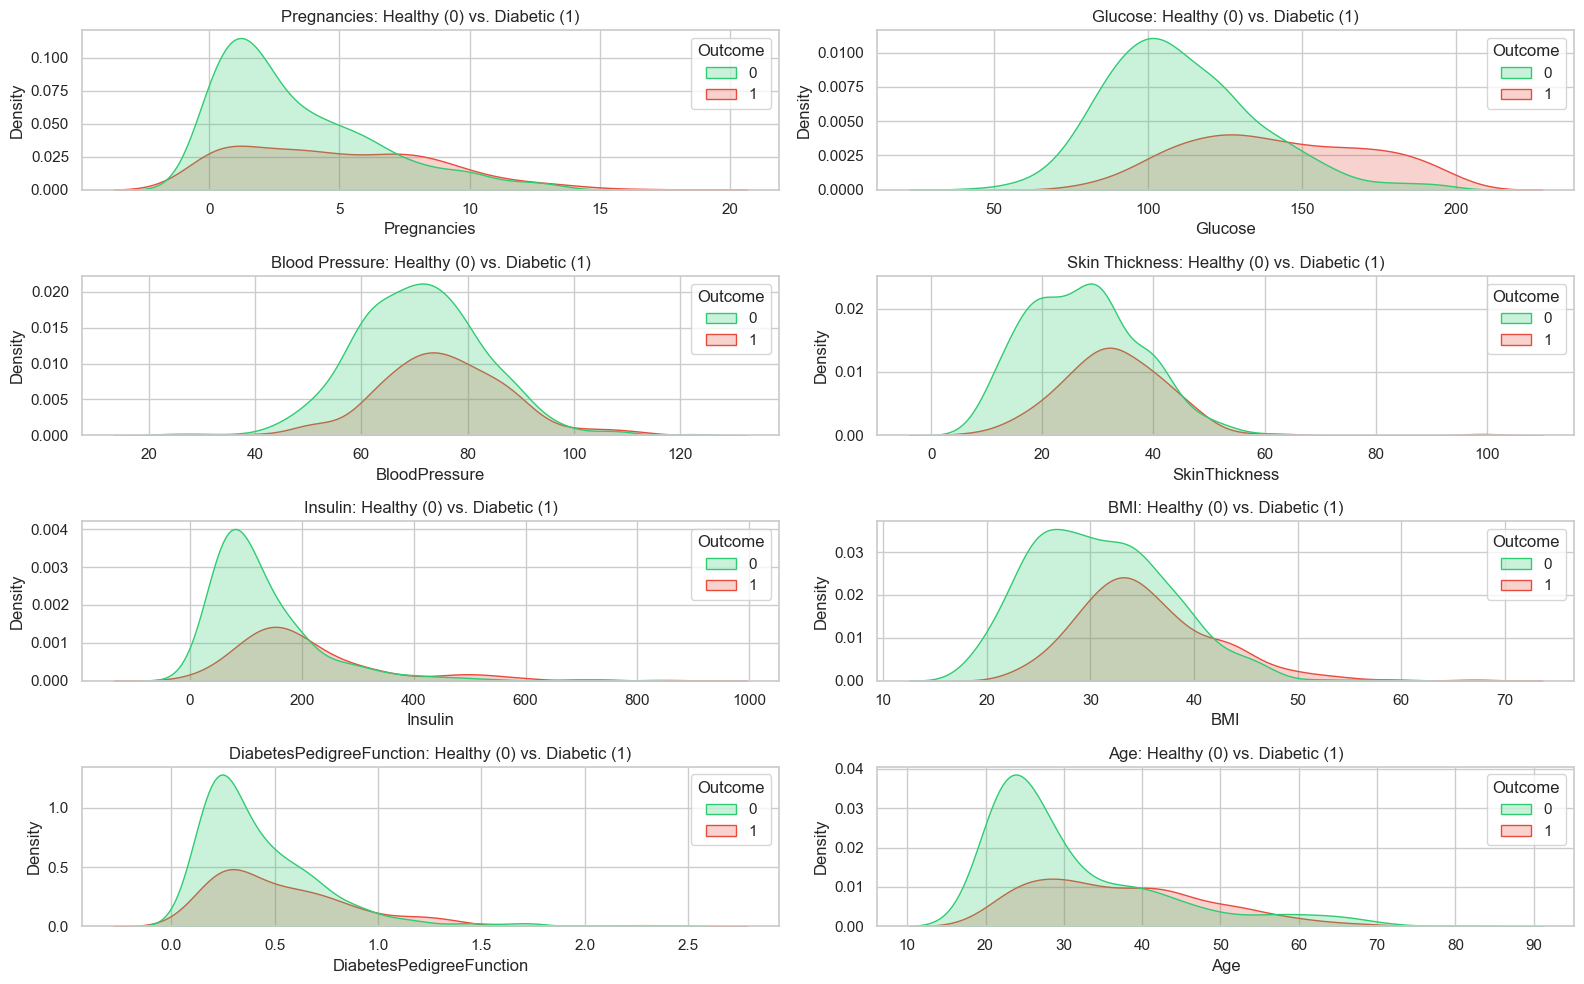

In [10]:
fig, axes = plt.subplots(4, 2, figsize=(16, 10))

# Green for healthy & red for diabetic individuals
my_palette = ['#2ecc71', '#e74c3c']

# KDE Plot for Pregnancies
sns.kdeplot(data=df, x='Pregnancies', hue='Outcome', fill=True, ax=axes[0, 0], palette=my_palette)
axes[0, 0].set_title('Pregnancies: Healthy (0) vs. Diabetic (1)')

# KDE Plot for Glucose
sns.kdeplot(data=df, x='Glucose', hue='Outcome', fill=True, ax=axes[0, 1], palette=my_palette)
axes[0, 1].set_title('Glucose: Healthy (0) vs. Diabetic (1)')

# KDE Plot for BloodPressure 
sns.kdeplot(data=df, x='BloodPressure', hue='Outcome', fill=True, ax=axes[1, 0], palette=my_palette)
axes[1, 0].set_title('Blood Pressure: Healthy (0) vs. Diabetic (1)')

# KDE Plot for SkinThickness
sns.kdeplot(data=df, x='SkinThickness', hue='Outcome', fill=True, ax=axes[1, 1], palette=my_palette)
axes[1, 1].set_title('Skin Thickness: Healthy (0) vs. Diabetic (1)')

# KDE Plot for Insulin
sns.kdeplot(data=df, x='Insulin', hue='Outcome', fill=True, ax=axes[2, 0], palette=my_palette)
axes[2, 0].set_title('Insulin: Healthy (0) vs. Diabetic (1)')

# KDE Plot for BMI
sns.kdeplot(data=df, x='BMI', hue='Outcome', fill=True, ax=axes[2, 1], palette=my_palette)
axes[2, 1].set_title('BMI: Healthy (0) vs. Diabetic (1)')

# KDE Plot for DiabetesPedigreeFunction
sns.kdeplot(data=df, x='DiabetesPedigreeFunction', hue='Outcome', fill=True, ax=axes[3, 0], palette=my_palette)
axes[3, 0].set_title('DiabetesPedigreeFunction: Healthy (0) vs. Diabetic (1)')

# KDE Plot for Age
sns.kdeplot(data=df, x='Age', hue='Outcome', fill=True, ax=axes[3, 1], palette=my_palette)
axes[3, 1].set_title('Age: Healthy (0) vs. Diabetic (1)')



plt.tight_layout()
plt.show()



### Interpretation of KDE Plot
- Wherever the red peak (diabetic) shifts to the right of the green peak (healthy) towards higher values, it indicates that the feature has a significant impact on diabetes.
  

Pregnancies:

- The red peak is shifted to the right compared to the green one. This shows a positive correlation: as the number of pregnancies increases, the risk of developing diabetes generally increases as well.

Glucose:

- Diabetic individuals have significantly higher glucose levels. This feature has very high discriminative power.

BloodPressure:

- The green and red curves are largely overlapping, which means this feature has low discriminative power on its own.


SkinThickness:

- Skin thickness reflects subcutaneous fat, which is related to insulin resistance. If the red curve shifts to the right, it shows that people with thicker skin have a higher risk.


Insulin:

- The red curve is highly right-skewed, suggesting that diabetic patients tend to have abnormal or higher insulin levels.

BMI:

- Obesity or being overweight is a key factor. The red plot shows higher density for values above 30 (the obesity borderline).


DiabetesPedigreeFunction (Genetic History):

- The red curve is slightly shifted to the right and has a thicker tail. This indicates that individuals with a higher genetic predisposition (a higher pedigree score) have a greater probability of diabetes.

Age:

- The red peak is usually a bit wider and skewed to the right. As age increases, the probability of diabetes increases as well, although younger people can also be affected.


---------------

### 6.2 Correlation Heatmap plot for Biological features

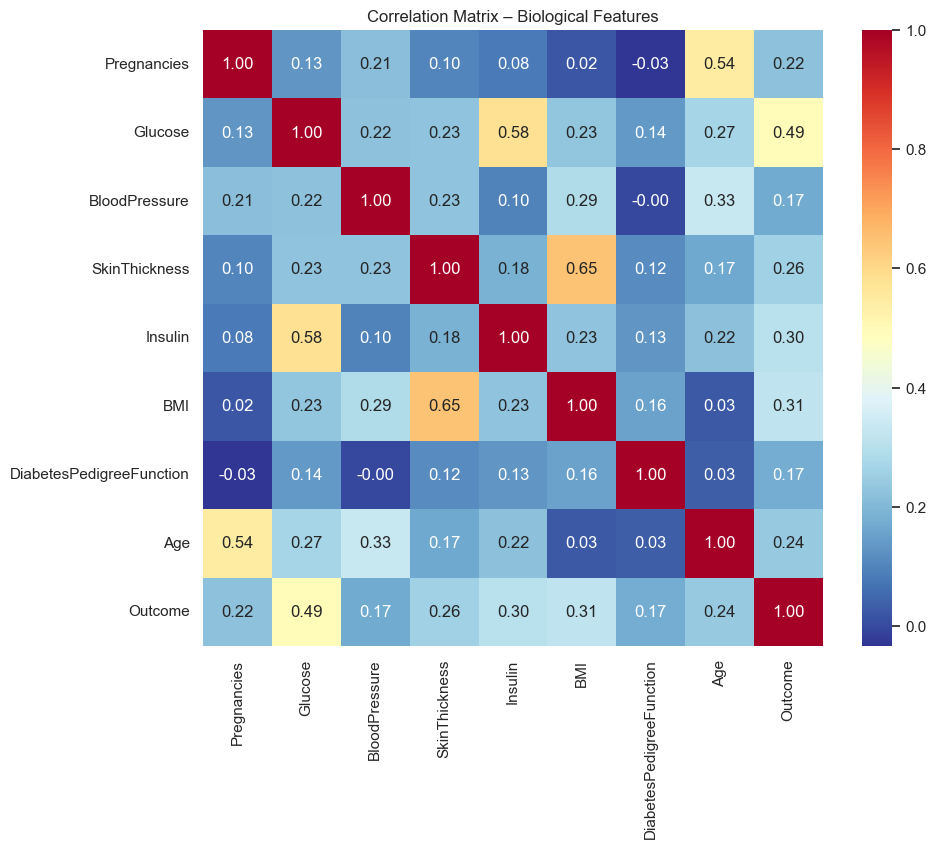

In [11]:
# Create correlation matrix for all features including Outcome
plt.figure(figsize=(10, 8))

sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='RdYlBu_r')
plt.title("Correlation Matrix – Biological Features")
plt.show()


### Interpretation of Correlation Heatmap plot

- Glucose has the most correlation with Outcome (0.49) that it makes sense in clinical terms.
- BMI(0.31) & Age(0.24) are also important.
- There is a moderate positive correlation between BMI and SkinThickness (0.54), as well as between Age and Pregnancies (0.54). This implies that these pairs share some overlapping biological information.
- Weak Predictors: BloodPressure shows a relatively weak correlation with Outcome (0.17), indicating it might not be a strong predictor for diabetes in this dataset.


---


### 6.3 Histogram Plot of Glucose levels by diabetes status

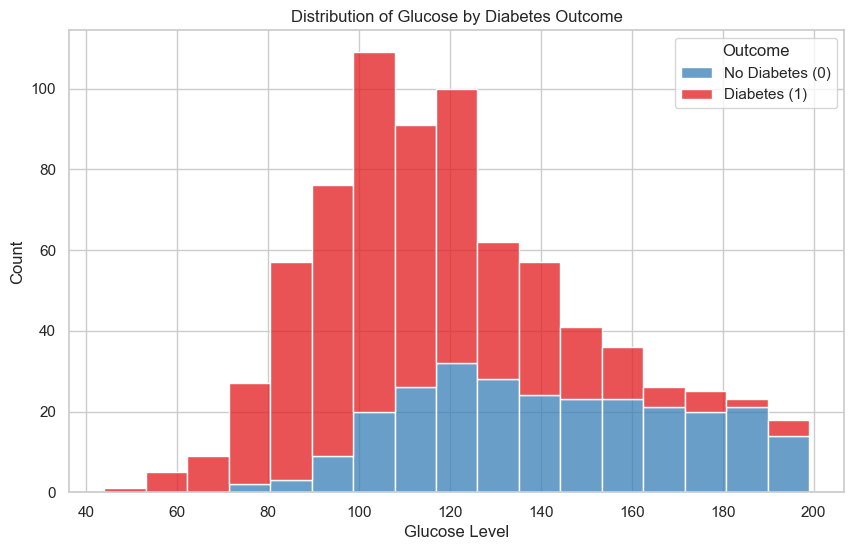

In [12]:
#Stacked histogram to compare class distributions in the same space
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x='Glucose',
    hue='Outcome',
    multiple='stack', # Stack classes to highlight proportional difference
    palette='Set1')
plt.title('Distribution of Glucose by Diabetes Outcome')
plt.xlabel('Glucose Level')
plt.ylabel('Count')
plt.legend(title='Outcome', labels=['No Diabetes (0)', 'Diabetes (1)'])
plt.show()

### Interpretation of Histogram Plot
- Diabetic patients(1) tend to have higher glucose levels, suggesting glucose is a strong predictive feature.

-------------------------------

### 6.4 Scatter Plot for seeing how Age and Glucose are related to Diabetes


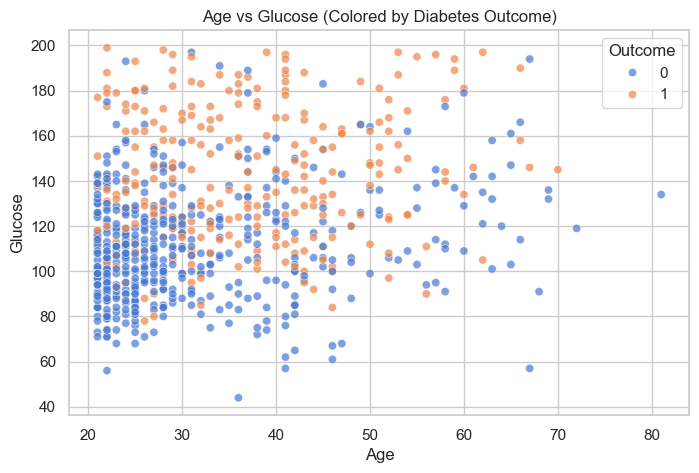

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Age',
    y='Glucose',
    hue='Outcome',
    alpha=0.7)     # Slight transparency to reduce overlap
plt.title('Age vs Glucose (Colored by Diabetes Outcome)')
plt.show()

### Interpretation of Scatter Plot
- Patients with diabetes generally show higher glucose levels.
- Age alone does not create a clear separation between the two classes.
- This suggests that glucose may be a stronger predictor of diabetes than age.
---

### 6.5 Box plot of BMI

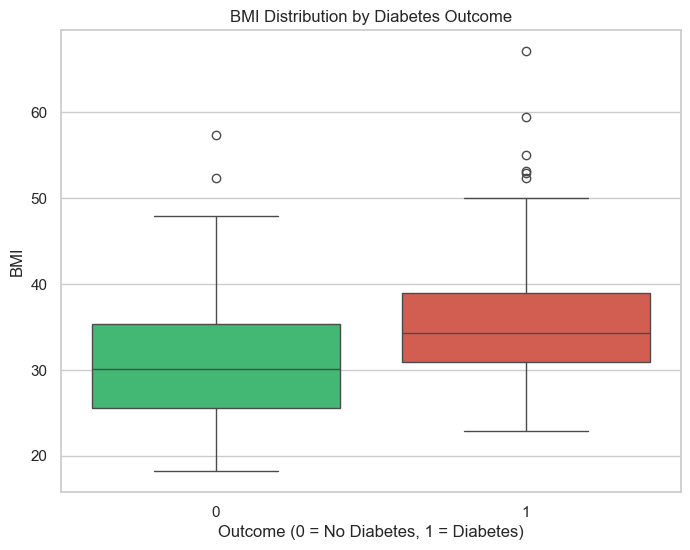

In [14]:
# Boxplot of BMI by diabetes status
plt.figure(figsize=(8, 6))
sns.boxplot(
    x='Outcome',
    y='BMI',
    data=df,
    hue='Outcome',
    palette=['#2ecc71', '#e74c3c'],
    legend=False)
plt.title('BMI Distribution by Diabetes Outcome')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('BMI')
plt.show()

### Interpretation of Box Plot
- Patients with diabetes tend to have higher BMI values compared to non-diabetic patients.
- The diabetic group also shows a wider spread of BMI values.
- This suggests that BMI may be an important feature in diabetes prediction.
---

### 6.6 Probability of Diabetes by Number of Pregnancies - Bar Plot

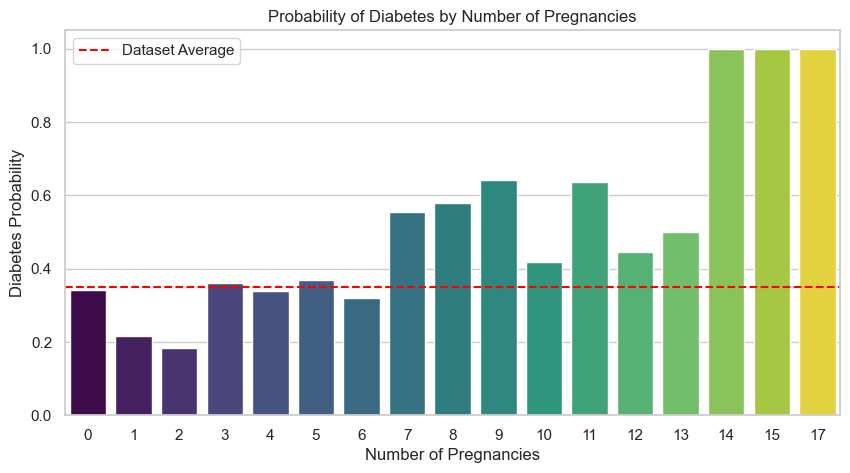

In [15]:

# Calculate diabetes probability by number of pregnancies
preg_prob = df.groupby('Pregnancies')['Outcome'].mean()


plt.figure(figsize=(10, 5))

sns.barplot(             # Draw a bar plot showing diabetes probability for each pregnancy count
    x=preg_prob.index,
    y=preg_prob.values,
    hue=preg_prob.index,
    palette='viridis',
    legend=False
)

plt.title('Probability of Diabetes by Number of Pregnancies')
plt.xlabel('Number of Pregnancies')
plt.ylabel('Diabetes Probability')

plt.axhline(              # a red dashed line showing the average diabetes probability across the whole dataset
    df['Outcome'].mean(),
    color='red',
    linestyle='--',
    label='Dataset Average')

plt.legend()
plt.show()


### Interpretation of The Bar Plot

- Diabetes probability increases as the number of pregnancies rises and most values above the dataset average appear in higher pregnancy groups.

---



## 7. Data Splitting & Scaling
### Train/Test Split & Pipeline‑Based Preprocessing



1. Separate features and target
2. Split data into train/test sets
3. Scale features for better model performance


### 7.1 Train/Test Split

In [16]:
# Split features and target
X = df.drop('Outcome', axis=1)   # Select the input features (all columns except Outcome)
y = df['Outcome']                # Select the target variable (Outcome column)

# Split dataset into train and test (70%-30%) with stratification for class balance
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,               # test_size sets how much data is for testing
    stratify=y,                  # stratify preserves class balance
    random_state=42              # random_state ensures reproducibility
)


# Check the class distribution after splitting
print('Train set class distribution:\n', y_train.value_counts(normalize=True))
print('Test set class distribution:\n', y_test.value_counts(normalize=True))


Train set class distribution:
 Outcome
0    0.651769
1    0.348231
Name: proportion, dtype: float64
Test set class distribution:
 Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


- Features and target are separated to keep the model inputs clean.
- The distribution check is separate to verify that stratification worked properly.

---

### 7.2 Pipelines for Data Preprocessing and Model Training


In [17]:
# 1. Pipeline for Logistic Regression
# Includes Imputation, Scaling, and the Model
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Handling zeros/missing values
    ('scaler', RobustScaler()),                   # Scaling features
    ('lr', LogisticRegression(random_state=42))    # The model
])

# 2. Pipeline for Random Forest
# Includes Imputation and the Model
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Handling zeros/missing values
    ('rf', RandomForestClassifier(random_state=42)) # The model
])

# Fit both pipelines on the training data.
# This automatically handles preprocessing within the training process. 
lr_pipeline.fit(X_train, y_train)   
rf_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a featu

- Pipelines were used to make the preprocessing and model training process more organized and reliable.
- One important reason for using pipelines is to prevent data leakage.
- Data leakage happens when information from the test data accidentally affects the training process.
- By using a pipeline, preprocessing steps are fitted only on the training data and then applied to the test data. This keeps the evaluation fair.

In this pipeline:

- Median imputation replaces missing or invalid values with the median of each feature.
- RobustScaler is used because it is more resistant to outliers and works better when extreme values exist.

- Scaling is important for Logistic Regression because this model is sensitive to the scale of features.
- Variables with larger values can influence the model more if scaling is not applied.
- Random Forest does not need feature scaling. Tree-based models split the data using feature thresholds, so they are not affected by differences in feature scale. For this reason, the Random Forest pipeline only includes the imputation step.
- ---

## 8. Model Training & Evaluation

### 8.1 Function to Evaluate Classification Models

In [18]:
# Function to print classification report
def evaluate_model(model_name, y_test, y_pred):

    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nModel: {model_name}")
    print(f"Accuracy: {accuracy:.4f}\n")

    print("Classification Report")
    print(classification_report(
        y_test,
        y_pred,
        target_names=['No Diabetes', 'Diabetes']
    ))

    return accuracy


- This function is used to evaluate the performance of classification models.
- It calculates the model accuracy, prints a detailed classification report.
- The function computes the accuracy score, which shows the overall percentage of correct predictions made by the model.
- It prints the classification report, which includes precision, recall, and F1-score for each class.These metrics provide a more detailed view of the model’s performance for predicting diabetic and non‑diabetic cases.
---

### 8.2 Random Forest with Pipeline


* Training model
* Preddiction
* Evaluation

In [19]:
# Train the pipeline (includes imputation + model training)
rf_pipeline.fit(X_train, y_train)

# Predict using the trained pipeline
rf_pred = rf_pipeline.predict(X_test)

# Evaluate the model
rf_accuracy = evaluate_model("Random Forest", y_test, rf_pred)




Model: Random Forest
Accuracy: 0.7489

Classification Report
              precision    recall  f1-score   support

 No Diabetes       0.78      0.86      0.82       150
    Diabetes       0.68      0.54      0.60        81

    accuracy                           0.75       231
   macro avg       0.73      0.70      0.71       231
weighted avg       0.74      0.75      0.74       231



### 8.3 Logistic Regression with Pipeline


* Training model
* Preddiction
* Evaluation

In [20]:
# Train the pipeline (includes imputation + scaling + model training)
lr_pipeline.fit(X_train, y_train)

# Predict using the trained pipeline
lr_pred = lr_pipeline.predict(X_test)

# Evaluate the model
lr_accuracy = evaluate_model("Logistic Regression", y_test, lr_pred)



Model: Logistic Regression
Accuracy: 0.7446

Classification Report
              precision    recall  f1-score   support

 No Diabetes       0.77      0.86      0.81       150
    Diabetes       0.67      0.53      0.59        81

    accuracy                           0.74       231
   macro avg       0.72      0.70      0.70       231
weighted avg       0.74      0.74      0.74       231



---

### 8.4 Confusion Matrix

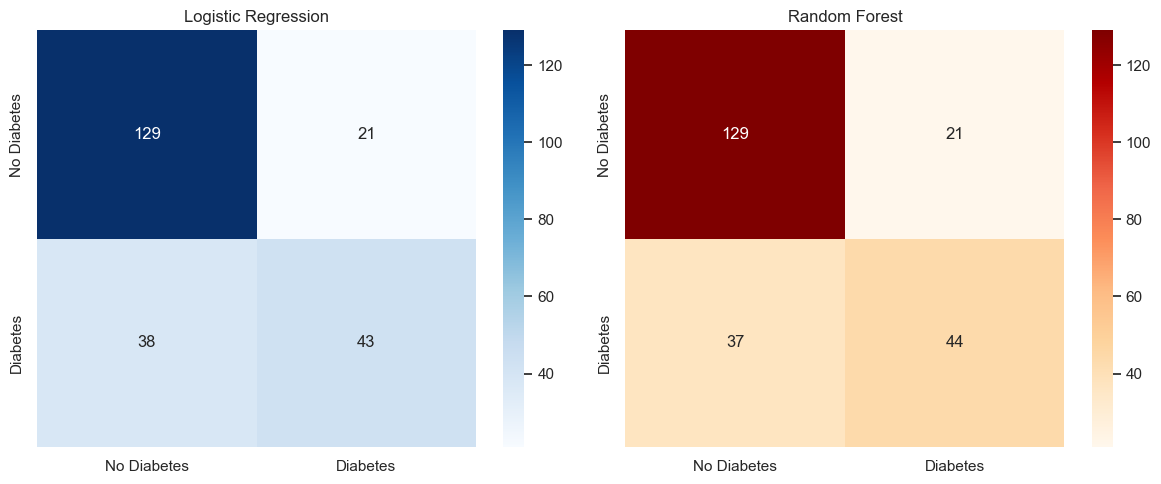

In [21]:
# Create two plots side by side to compare the models
fig, axes = plt.subplots(1, 2, figsize=(12,5))


# Compute confusion matrix for Logistic Regression predictions
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes','Diabetes'],   # Predicted labels
            yticklabels=['No Diabetes','Diabetes'],   # Actual labels
            ax=axes[0])

axes[0].set_title("Logistic Regression")




# Compute confusion matrix for Random Forest predictions
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='OrRd',
            xticklabels=['No Diabetes','Diabetes'],   # Predicted labels
            yticklabels=['No Diabetes','Diabetes'],   # Actual labels
            ax=axes[1])

axes[1].set_title("Random Forest")


plt.tight_layout()
plt.show()


- Confusion Matrix is used to evaluate classification models by showing the number of correct and incorrect predictions. 
- It helps understand how well the model distinguishes between diabetic and non‑diabetic cases by displaying True Positives, True Negatives, False Positives, and False Negatives.

- Both models show similar performance in the confusion matrices.
- Logistic Regression correctly identified 43 diabetic patients, while Random Forest identified 44. 
- Random Forest slightly reduced false negative predictions, meaning it missed fewer diabetic cases, which is important in medical prediction tasks.

---

### 8.5 ROC Curve and AUC Analysis

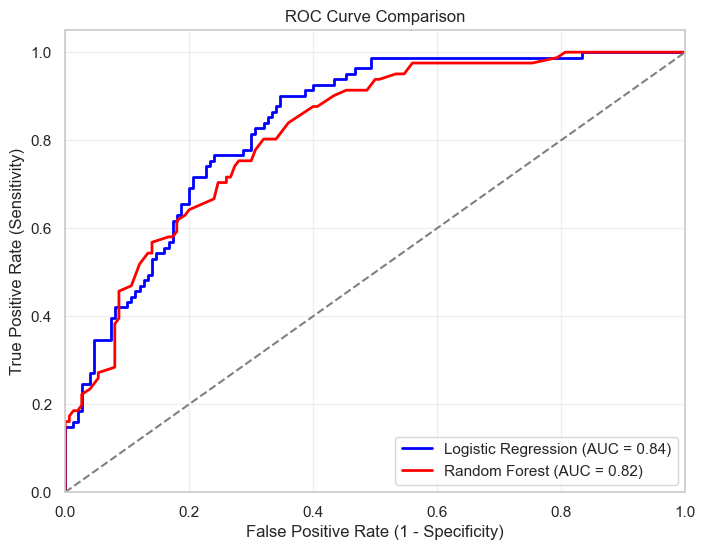

In [22]:
from sklearn.metrics import roc_curve, auc

# Get prediction probabilities for the positive class (Diabetes)
# predict_proba returns probabilities for both classes, so we select column 1 (positive class)
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]
rf_probs = rf_pipeline.predict_proba(X_test)[:, 1]


#Calculate False Positive Rate (FPR) and True Positive Rate (TPR) for Logistic Regression to draw the ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)


# Compute the Area Under the Curve (AUC)
roc_auc_lr = auc(fpr_lr, tpr_lr)


# Compute the Area Under the Curve (AUC)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

# Calculate AUC score for Random Forest
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))

# Plot ROC curve for Logistic Regression
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')

# Plot ROC curve for Random Forest
plt.plot(fpr_rf, tpr_rf, color='red', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

# Plot a diagonal dashed line which represents a random classifier
# Any useful model should perform above this line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])      # Define the limits of the x-axis
plt.ylim([0.0, 1.05])     # Define the limits of the y-axis

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)       # Add a light grid to improve readability of the plot

plt.show()


- The ROC curve shows how well the model separates diabetic and non-diabetic cases.
- The x-axis (False Positive Rate) represents wrong positive predictions, and the y-axis (True Positive Rate) shows correctly predicted positives.
- Each point corresponds to a different decision threshold.
- The AUC (Area Under the Curve) summarizes the model performance:


### Interpretation of This Plot
- Both models perform well, as their curves lie above the random line.
- Logistic Regression (AUC = 0.84) slightly outperforms Random Forest (AUC = 0.82).
- Overall, both demonstrate good ability to distinguish diabetic from non-diabetic patients.




---

### 8.6 Model Performance Comparison

Create a table to compare the performance of Logistic Regression and Random Forest using common classification metrics

In [23]:
comparison = pd.DataFrame({

    "Model": ["Logistic Regression", "Random Forest"],

    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],

    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],

    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ]

})

comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.744589,0.671875,0.530864,0.593103
1,Random Forest,0.748918,0.676923,0.543210,0.602740


Based on the comparison table:

- Random Forest achieved slightly higher accuracy (74.8%) and F1 score (60.2%), suggesting it performs slightly better on this dataset. However, the difference between the two models is relatively small.

- The results of both models are quite similar, which may indicate that the relationship between the features and the target variable can be captured reasonably well by both a linear model and a tree-based model.

- Both models show relatively low Recall (around 53–54%). This means that nearly half of the actual diabetes cases are not correctly identified. In a medical context, this is an important limitation, since missing a potential diagnosis can have serious consequences.

- Overall, while Random Forest performs slightly better, both models still have room for improvement, particularly in identifying more positive diabetes cases (improving Recall).
---

## 9. Most Important Features in Diabetes Prediction (using Random Forest)


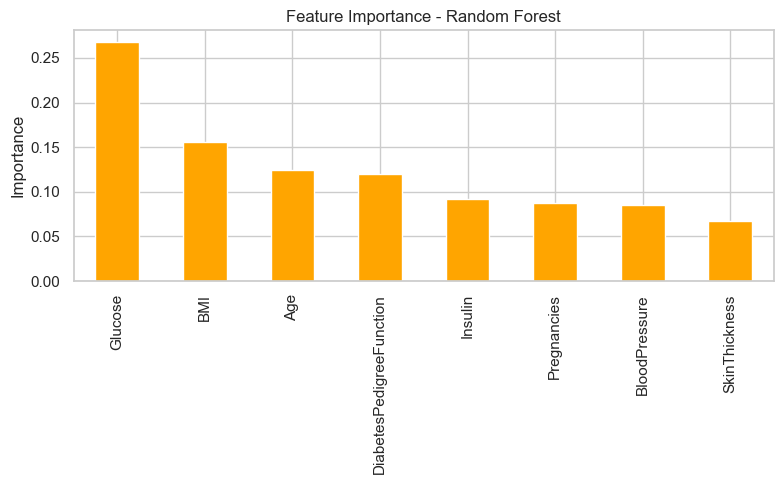

Top features:
Glucose                     0.267455
BMI                         0.155972
Age                         0.124982
DiabetesPedigreeFunction    0.119556
Insulin                     0.091711
Pregnancies                 0.087162
BloodPressure               0.085607
SkinThickness               0.067557
dtype: float64


In [28]:
# Get the trained Random Forest model from pipeline
rf_model = rf_pipeline.named_steps["rf"]

# Extract feature importance
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Plot feature importance
plt.figure(figsize=(8,5))
importances.plot(kind="bar", color="orange")

plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance")

plt.tight_layout()
plt.show()

print("Top features:")
print(importances.head(8))


- The plot shows the most influential features used by the Random Forest model for diabetes prediction.
- Glucose and BMI had the highest impact on the model’s decisions.

--------------------------

## 10. Cross Validation

- To better evaluate the models, 5-fold cross-validation was applied to the training data.
- In this method, the training dataset is divided into five parts. In each iteration, four parts are used for training and one part is used for validation.
- This process is repeated five times so that each part of the data is used once for validation.
- Cross-validation helps provide a more reliable estimate of model performance and reduces the chance that the results depend on a single train-test split.
- By comparing the cross-validation scores of Logistic Regression and Random Forest, we can see which model performs more consistently across different subsets of the data

### 10.1 Perform Cross-Validation on Logistic Regression Pipeline

In [24]:
cv_scores_lr = cross_val_score(lr_pipeline, X_train, y_train, cv=5, scoring="accuracy")

print("Logistic Regression Cross Validation Scores:", cv_scores_lr)
print("Mean CV Accuracy:", np.mean(cv_scores_lr))


Logistic Regression Cross Validation Scores: [0.80555556 0.78703704 0.79439252 0.79439252 0.71028037]
Mean CV Accuracy: 0.7783316026306681


### 10.2 Perform Cross-Validation on Random Forest Pipeline

In [25]:
# Perform cross-validation on Random Forest pipeline
cv_scores_rf = cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring="accuracy")

print("Random Forest Cross Validation Scores:", cv_scores_rf)
print("Mean CV Accuracy:", np.mean(cv_scores_rf))


Random Forest Cross Validation Scores: [0.75       0.75       0.76635514 0.75700935 0.78504673]
Mean CV Accuracy: 0.7616822429906542


### Cross-Validation Results
- The results of the 5-fold cross-validation show that both models achieve relatively consistent performance across different splits of the training data.
- Logistic Regression achieved a mean cross-validation accuracy of approximately 0.78, while Random Forest achieved a mean accuracy of about 0.76. 
- This suggests that Logistic Regression performs slightly better on average during cross-validation.
- Both models demonstrate reasonable generalization ability, with Logistic Regression showing a small advantage in cross-validation performance.
---

## 11. Final Comparison of Models

- To evaluate the performance of Logistic Regression and Random Forest, several metrics were used, including accuracy, F1-score, confusion matrices, ROC-AUC, and cross-validation.
- The results show that Random Forest achieved slightly higher accuracy and F1-score than Logistic Regression. 
- However, Logistic Regression obtained a higher ROC-AUC score and slightly better cross-validation results.
- The confusion matrices show that both models correctly identify many non-diabetic patients, but they still miss a number of actual diabetes cases. This means the recall for diabetic patients is relatively low.
- Overall, the performance of the two models is very similar.
- Random Forest performs slightly better in accuracy, while Logistic Regression shows better ROC-AUC and more stable cross-validation results.

These results suggest that both models have limitations in detecting all positive diabetes cases.
Improving recall would be an important goal for future work.


---


## 12. Conclusion
- This project explored the use of machine learning models to predict diabetes based on patient health indicators.
- Two models were implemented: Logistic Regression and Random Forest. Both models showed similar performance, although Random Forest achieved slightly better results in terms of accuracy and F1-score.
- The evaluation using confusion matrices, ROC curves, and classification metrics helped provide a clearer understanding of how the models perform. 
- Overall, the models demonstrate that machine learning can be useful for identifying potential diabetes risk, although the results also show that prediction accuracy is still limited.

---

## 13. Summary
- In this project, a diabetes dataset was analyzed and prepared using preprocessing techniques such as handling missing values and feature scaling. 
- Two classification models were trained and evaluated: Logistic Regression and Random Forest. 
- Their performance was compared using several metrics including accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices. The results showed that Random Forest performed slightly better, but both models produced comparable outcomes
---

## 14. Limitations
- One limitation of this project is that the dataset is relatively small and may not fully represent the diversity of real patient populations.
- In addition, the models show relatively low recall, meaning that some diabetes cases are not correctly identified. 
- Another limitation is that only two machine learning models were tested and no advanced techniques such as hyperparameter tuning or class balancing were applied. 
- Because of these limitations, the models should not be considered reliable for real medical decision-making.
---

## 15. Medical Explanation
- Diabetes is a chronic condition that affects how the body processes blood glucose. 
- Early detection is important because untreated diabetes can lead to serious complications such as heart disease, kidney damage, and nerve problems. 
- Machine learning models can help analyze patterns in patient data and identify individuals who may be at higher risk. 
- However, these models are meant to support medical professionals rather than replace clinical diagnosis.
---

## 16. Future Work
- Future improvements could include testing additional machine learning models such as Gradient Boosting or Support Vector Machines. 
- Applying hyperparameter tuning could also improve model performance. 
- Another important improvement would be handling class imbalance or collecting larger and more diverse datasets. 
- In addition, more advanced evaluation techniques could be used to better understand how the models generalize to new data.
---

## References

- UCI Machine Learning Repository – Pima Indians Diabetes Dataset  
https://archive.ics.uci.edu/ml/datasets/pima+indians+diabetes

- Scikit-learn Documentation  
https://scikit-learn.org/stable/

- World Health Organization (WHO) – Diabetes Overview  
https://www.who.int/health-topics/diabetes

- American Diabetes Association – Diabetes Information  
https://diabetes.org/about-diabetes


---


By : Sahel Sepehri
- github.com/sahelsepehri
- sahelsepehri99@gmail.com